# WM9B7 EEG Workload Classification - Implementation Notebook

This is the main implementation notebook for the individual assignment.

## How to use this notebook
1. Run cells in order from top to bottom.
2. Keep all outputs needed for evidence in the report.
3. Do not remove section headings; they map to report and marking criteria.

## Scope
- Task: MATB workload classification (easy, med, diff).
- Protocol: Cross-session (train S1+S2, test S3).
- Baselines: SVM + EEGNet.

## 1. Environment and Reproducibility Setup

In [1]:
import os
import sys
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version

try:
    import torch
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

if TORCH_AVAILABLE:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Plot style for consistent figures
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 20)

# Resolve project root robustly
cwd = Path.cwd().resolve()
if (cwd / "dataset").exists():
    PROJECT_ROOT = cwd
elif cwd.name == "notebooks" and (cwd.parent / "dataset").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"Project root: {PROJECT_ROOT}")
print(f"MNE: {mne.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn_version}")
if TORCH_AVAILABLE:
    print(f"PyTorch: {torch.__version__} | CUDA available: {torch.cuda.is_available()}")
else:
    print("PyTorch: not installed")
print(f"Seed: {SEED}")

Python: 3.14.3
Platform: Windows-11-10.0.26200-SP0
Project root: C:\Users\u5749675\Desktop\u5749675\eeg-workload-classification
MNE: 1.12.1
NumPy: 2.4.4
Pandas: 3.0.2
scikit-learn: 1.8.0
PyTorch: 2.11.0+cu128 | CUDA available: True
Seed: 42


## 2. Data Source Configuration (Local or Remote)

Use a single switch variable so the same notebook works for development and final submission checks.

In [2]:
from zipfile import ZipFile
import requests

# Data source mode: use local for development, switch to remote before final reproducibility check
DATA_SOURCE_MODE = "local"  # "local" or "remote"
REMOTE_PROVIDER = "gdrive"  # "gdrive" or "direct"

# Remote config placeholders (fill before final submission run)
REMOTE_FILE_ID = ""
REMOTE_DIRECT_URL = ""
REMOTE_ARCHIVE_NAME = "matb_dataset.zip"

LOCAL_DATASET_DIR = PROJECT_ROOT / "dataset"
REMOTE_CACHE_DIR = PROJECT_ROOT / "data_remote_cache"

def _download_from_gdrive(file_id: str, output_path: Path) -> None:
    if not file_id:
        raise ValueError("REMOTE_FILE_ID is empty. Set your Google Drive file ID first.")
    try:
        import gdown
    except ImportError as exc:
        raise ImportError("Install gdown before remote run: pip install gdown") from exc

    output_path.parent.mkdir(parents=True, exist_ok=True)
    gdown.download(id=file_id, output=str(output_path), quiet=False, fuzzy=True)

def _download_from_direct_url(url: str, output_path: Path) -> None:
    if not url:
        raise ValueError("REMOTE_DIRECT_URL is empty. Set a valid dataset URL first.")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with requests.get(url, stream=True, timeout=180) as response:
        response.raise_for_status()
        with open(output_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)

def _resolve_extracted_dataset_dir(base_dir: Path) -> Path:
    # Common cases: base_dir/dataset or nested */dataset
    direct = base_dir / "dataset"
    if direct.exists():
        return direct
    candidates = list(base_dir.rglob("dataset"))
    candidates = [c for c in candidates if c.is_dir() and (c / "sub-01").exists()]
    if candidates:
        return candidates[0]
    raise FileNotFoundError("Could not locate extracted dataset directory.")

def resolve_dataset_dir(mode: str) -> Path:
    mode = mode.lower().strip()
    if mode not in {"local", "remote"}:
        raise ValueError("DATA_SOURCE_MODE must be 'local' or 'remote'.")

    if mode == "local":
        if not LOCAL_DATASET_DIR.exists():
            raise FileNotFoundError(f"Local dataset folder not found: {LOCAL_DATASET_DIR}")
        return LOCAL_DATASET_DIR

    # Remote mode
    REMOTE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    archive_path = REMOTE_CACHE_DIR / REMOTE_ARCHIVE_NAME
    extract_root = REMOTE_CACHE_DIR / "extracted"

    if not archive_path.exists():
        print("Remote archive not found locally. Downloading...")
        if REMOTE_PROVIDER == "gdrive":
            _download_from_gdrive(REMOTE_FILE_ID, archive_path)
        elif REMOTE_PROVIDER == "direct":
            _download_from_direct_url(REMOTE_DIRECT_URL, archive_path)
        else:
            raise ValueError("REMOTE_PROVIDER must be 'gdrive' or 'direct'.")

    if not extract_root.exists():
        print("Extracting dataset archive...")
        extract_root.mkdir(parents=True, exist_ok=True)
        with ZipFile(archive_path, "r") as zf:
            zf.extractall(extract_root)

    return _resolve_extracted_dataset_dir(extract_root)

DATASET_DIR = resolve_dataset_dir(DATA_SOURCE_MODE)
print(f"Data source mode: {DATA_SOURCE_MODE}")
print(f"Dataset directory: {DATASET_DIR}")

Data source mode: local
Dataset directory: C:\Users\u5749675\Desktop\u5749675\eeg-workload-classification\dataset


## 3. Dataset Discovery and Integrity Checks

In [3]:
# Build a file index from MATB .set files
matb_files = sorted([p for p in DATASET_DIR.rglob("*.set") if p.stem.lower().startswith("matb")])
if not matb_files:
    raise FileNotFoundError(f"No MATB .set files found under: {DATASET_DIR}")

records = []
for fp in matb_files:
    subject = next((x for x in fp.parts if x.startswith("sub-")), "unknown")
    session = next((x for x in fp.parts if x.startswith("ses-")), "unknown")
    level = fp.stem.lower().replace("matb", "")
    fdt_exists = fp.with_suffix(".fdt").exists()
    records.append({
        "subject": subject,
        "session": session,
        "level": level,
        "set_file": fp,
        "fdt_exists": fdt_exists,
    })

FILE_INDEX_DF = pd.DataFrame(records)
if FILE_INDEX_DF.empty:
    raise RuntimeError("File index is empty after MATB scan.")

# Deterministic sort
FILE_INDEX_DF["subject_num"] = FILE_INDEX_DF["subject"].str.extract(r"sub-(\d+)").astype(int)
session_rank = {"ses-S1": 1, "ses-S2": 2, "ses-S3": 3}
FILE_INDEX_DF["session_rank"] = FILE_INDEX_DF["session"].map(session_rank).fillna(999).astype(int)
FILE_INDEX_DF = FILE_INDEX_DF.sort_values(["subject_num", "session_rank", "level"]).reset_index(drop=True)

# Integrity checks
expected_levels = {"easy", "med", "diff"}
levels_found = set(FILE_INDEX_DF["level"].unique())
if not expected_levels.issubset(levels_found):
    missing_levels = expected_levels - levels_found
    raise AssertionError(f"Missing expected MATB levels: {missing_levels}")

missing_fdt = int((~FILE_INDEX_DF["fdt_exists"]).sum())
if missing_fdt > 0:
    raise AssertionError(f"Found {missing_fdt} .set files without matching .fdt files.")

triplet_df = (
    FILE_INDEX_DF.groupby(["subject", "session"])["level"]
    .apply(set)
    .reset_index(name="levels_present")
)
bad_triplets = triplet_df[triplet_df["levels_present"] != expected_levels]
if not bad_triplets.empty:
    raise AssertionError(
        "Some subject-session groups are missing MATB levels. "
        f"Examples: {bad_triplets.head(5).to_dict(orient='records')}"
    )

print("Dataset integrity checks passed.")
print(f"Total MATB files: {len(FILE_INDEX_DF)}")
print(f"Subjects: {FILE_INDEX_DF['subject'].nunique()}")
print(f"Sessions: {sorted(FILE_INDEX_DF['session'].unique())}")
print(f"Levels: {sorted(FILE_INDEX_DF['level'].unique())}")

display(FILE_INDEX_DF.groupby("level").size().rename("count").reset_index())
display(FILE_INDEX_DF.groupby("session").size().rename("count").reset_index())
display(FILE_INDEX_DF.head(10))

Dataset integrity checks passed.
Total MATB files: 261
Subjects: 29
Sessions: ['ses-S1', 'ses-S2', 'ses-S3']
Levels: ['diff', 'easy', 'med']


,level,count
0,diff,87
1,easy,87
2,med,87


,session,count
0,ses-S1,87
1,ses-S2,87
2,ses-S3,87


,subject,session,level,set_file,fdt_exists,subject_num,session_rank
0,sub-01,ses-S1,diff,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,1
1,sub-01,ses-S1,easy,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,1
2,sub-01,ses-S1,med,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,1
3,sub-01,ses-S2,diff,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,2
4,sub-01,ses-S2,easy,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,2
5,sub-01,ses-S2,med,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,2
6,sub-01,ses-S3,diff,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,3
7,sub-01,ses-S3,easy,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,3
8,sub-01,ses-S3,med,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,1,3
9,sub-02,ses-S1,diff,C:\Users\u5749675\Desktop\u5749675\eeg-workloa...,True,2,1


## 4. Label Mapping and Cross-Session Split

Mapping:
- MATBeasy -> 0
- MATBmed -> 1
- MATBdiff -> 2

Split:
- Train: S1 + S2
- Test: S3

In [4]:
LABEL_MAP = {"easy": 0, "med": 1, "diff": 2}
LABEL_NAMES = {0: "Low", 1: "Medium", 2: "High"}

DF = FILE_INDEX_DF.copy()
DF["label"] = DF["level"].map(LABEL_MAP).astype(int)
DF["split"] = np.where(DF["session"] == "ses-S3", "test", "train")

TRAIN_DF = DF[DF["split"] == "train"].reset_index(drop=True)
TEST_DF = DF[DF["split"] == "test"].reset_index(drop=True)

# Leakage and protocol assertions
assert set(TRAIN_DF["session"].unique()) <= {"ses-S1", "ses-S2"}, "Train split has invalid sessions."
assert set(TEST_DF["session"].unique()) == {"ses-S3"}, "Test split must only contain ses-S3."
assert set(TRAIN_DF["set_file"]).isdisjoint(set(TEST_DF["set_file"])), "File leakage detected between train and test."

# Ensure every subject appears in both train and test in this protocol
train_subjects = set(TRAIN_DF["subject"].unique())
test_subjects = set(TEST_DF["subject"].unique())
missing_train = sorted(list(test_subjects - train_subjects))
missing_test = sorted(list(train_subjects - test_subjects))
if missing_train or missing_test:
    raise AssertionError(
        f"Subject mismatch across splits. Missing in train: {missing_train}, missing in test: {missing_test}"
    )

print("Label mapping and split checks passed.")
print(f"Train files: {len(TRAIN_DF)}")
print(f"Test files: {len(TEST_DF)}")

print("\nTrain label distribution:")
display(TRAIN_DF.groupby(["level", "label"]).size().rename("count").reset_index())

print("Test label distribution:")
display(TEST_DF.groupby(["level", "label"]).size().rename("count").reset_index())

print("Split x session table:")
display(pd.crosstab(DF["split"], DF["session"]))

Label mapping and split checks passed.
Train files: 174
Test files: 87

Train label distribution:


,level,label,count
0,diff,2,58
1,easy,0,58
2,med,1,58


Test label distribution:


,level,label,count
0,diff,2,29
1,easy,0,29
2,med,1,29


Split x session table:


session,ses-S1,ses-S2,ses-S3
split,,,
test,0,0,87
train,87,87,0


## 5. Preprocessing Design (Chosen Core Pipeline + Optional ICA Branch)

We use a robust, reproducible pipeline optimized for cross-session evaluation and notebook Run All constraints.

### Core default pipeline (kept)
1. **Channel harmonization first**
- The dataset has mixed channel counts, so we enforce a common channel intersection to prevent shape mismatches.

2. **Filtering for cognitive EEG**
- Notch filter at 50 Hz for line noise.
- Band-pass 1-40 Hz (contains a 1 Hz high-pass component) to retain workload-relevant rhythms while reducing drift/high-frequency noise.

3. **Bad channel handling and referencing**
- Detect outlier channels with robust variance z-scores and interpolate them.
- Apply common average reference (CAR) for stable spatial comparability across sessions.

4. **Resampling and epoching**
- Resample to 250 Hz to reduce compute while preserving useful temporal information.
- Use **6-second windows** with overlap (based on prior sweep evidence).

5. **Artifact rejection and normalization**
- Drop windows with peak-to-peak amplitude > 150 uV.
- Fit normalization statistics on training windows only, then apply to test windows (leakage-safe).

### New addition: optional ICA blink-removal branch
- We add ICA as a controlled option rather than forcing it as default immediately.
- ICA is configured with safeguards (max excluded components, fallback if fitting fails).
- Promotion rule to default: keep ICA only if it consistently improves macro-F1 and Medium recall without unacceptable runtime increase.

### Implementation notes
- Cell 11: helper functions + ICA options
- Cell 12: preprocessing execution with configurable variants

In [5]:
from typing import Dict, List, Tuple

# -----------------------------
# Preprocessing configuration
# -----------------------------
PREPROC_CONFIG = {
    "montage": "standard_1020",
    "notch_hz": 50.0,
    "l_freq": 1.0,
    "h_freq": 40.0,
    "resample_hz": 250.0,
    "window_sec": 6.0,
    "overlap": 0.5,
    "artifact_thresh_uv": 150.0,
    "bad_ch_robust_z": 5.0,

    # ICA branch (optional, controlled by PREPROC_VARIANT in Cell 12)
    "ica_method": "fastica",
    "ica_n_components": 0.99,
    "ica_random_state": 42,
    "ica_fit_l_freq": 1.0,
    "ica_decim": 3,
    "ica_max_exclude": 2,
    "ica_use_frontal_proxy": True,
    "ica_fallback_channels": ["Fp1", "Fp2", "AF7", "AF8", "F7", "F8"],
}

def get_channel_sets(file_paths: List[Path]) -> List[set]:
    """Read channel names from each file (without preloading full data)."""
    channel_sets = []
    for fp in file_paths:
        raw = mne.io.read_raw_eeglab(str(fp), preload=False, verbose="ERROR")
        channel_sets.append(set(raw.ch_names))
    return channel_sets

def get_common_eeg_channels(file_paths: List[Path]) -> List[str]:
    """Compute common channel intersection and remove ECG channels."""
    if not file_paths:
        raise ValueError("file_paths is empty.")

    channel_sets = get_channel_sets(file_paths)
    common = sorted(list(set.intersection(*channel_sets)))
    common = [ch for ch in common if not ch.upper().startswith("ECG")]
    if not common:
        raise RuntimeError("No common EEG channels found after ECG exclusion.")
    return common

def robust_bad_channel_detection(raw: mne.io.BaseRaw, z_thresh: float = 5.0) -> List[str]:
    """Detect bad channels using robust z-score of log-variance."""
    ch_names = raw.ch_names
    X = raw.get_data()  # shape: (n_channels, n_times), Volts
    ch_var = np.var(X, axis=1) + 1e-20
    log_var = np.log(ch_var)

    med = np.median(log_var)
    mad = np.median(np.abs(log_var - med)) + 1e-12
    robust_z = 0.6745 * (log_var - med) / mad

    bad_idx = np.where(np.abs(robust_z) > z_thresh)[0]
    bads = [ch_names[i] for i in bad_idx]

    # Guardrail: avoid flagging too many channels in one go
    if len(bads) >= max(1, int(0.25 * len(ch_names))):
        return []
    return bads

def _pick_frontal_proxy_channel(raw: mne.io.BaseRaw, candidates: List[str]) -> str | None:
    """Pick a frontal channel as an EOG proxy when no EOG channel is present."""
    for ch in candidates:
        if ch in raw.ch_names:
            return ch
    return None

def apply_ica_blink_removal(raw: mne.io.BaseRaw, cfg: Dict, verbose: bool = False) -> Tuple[mne.io.BaseRaw, Dict]:
    """Fit ICA and remove likely blink components with safe fallbacks."""
    ica_stats = {
        "ica_applied": False,
        "ica_excluded": [],
        "ica_reason": "disabled",
        "ica_reference_channel": None,
    }

    try:
        ica_stats["ica_reason"] = "no_components_found"

        # Fit ICA on a high-pass copy (recommended for ICA stability).
        raw_for_ica = raw.copy().filter(
            l_freq=cfg["ica_fit_l_freq"],
            h_freq=None,
            method="fir",
            phase="zero",
            verbose="ERROR",
        )

        ica = mne.preprocessing.ICA(
            n_components=cfg["ica_n_components"],
            method=cfg["ica_method"],
            random_state=int(cfg["ica_random_state"]),
            max_iter="auto",
        )
        ica.fit(raw_for_ica, picks="eeg", decim=int(cfg["ica_decim"]), verbose="ERROR")

        eog_ch = None
        for ch, ch_type in zip(raw_for_ica.ch_names, raw_for_ica.get_channel_types()):
            if ch_type == "eog":
                eog_ch = ch
                break

        if eog_ch is None and cfg.get("ica_use_frontal_proxy", True):
            eog_ch = _pick_frontal_proxy_channel(raw_for_ica, cfg.get("ica_fallback_channels", []))

        ica_stats["ica_reference_channel"] = eog_ch

        eog_inds = []
        if eog_ch is not None:
            eog_inds, _ = ica.find_bads_eog(raw_for_ica, ch_name=eog_ch, verbose="ERROR")

        max_exclude = int(cfg.get("ica_max_exclude", 2))
        if len(eog_inds) > max_exclude:
            eog_inds = eog_inds[:max_exclude]

        ica_stats["ica_excluded"] = [int(i) for i in eog_inds]

        if len(eog_inds) > 0:
            raw_clean = raw.copy()
            ica.exclude = list(eog_inds)
            ica.apply(raw_clean, verbose="ERROR")
            ica_stats["ica_applied"] = True
            ica_stats["ica_reason"] = "applied"
            if verbose:
                print(f"ICA applied; excluded ICs={ica_stats['ica_excluded']} using channel={eog_ch}")
            return raw_clean, ica_stats

        ica_stats["ica_reason"] = "no_eog_like_components"
        if verbose:
            print("ICA skipped: no EOG-like components detected.")
        return raw, ica_stats

    except Exception as exc:
        ica_stats["ica_reason"] = f"failed:{type(exc).__name__}"
        if verbose:
            print(f"ICA failed; continuing without ICA. Reason: {exc}")
        return raw, ica_stats

def preprocess_single_block(
    set_file: Path,
    common_channels: List[str],
    cfg: Dict,
    verbose: bool = False,
    enable_bad_channel_interp: bool = True,
    enable_car: bool = True,
    enable_ica: bool = False,
) -> Tuple[mne.io.BaseRaw, Dict]:
    """Preprocess one continuous MATB block and return cleaned raw + processing stats."""
    raw = mne.io.read_raw_eeglab(str(set_file), preload=True, verbose="ERROR")

    # Keep and order channels consistently
    raw.pick(common_channels)

    # Montage
    raw.set_montage(cfg["montage"], on_missing="ignore", verbose="ERROR")

    # Filtering
    raw.notch_filter(freqs=[cfg["notch_hz"]], method="fir", phase="zero", verbose="ERROR")
    raw.filter(
        l_freq=cfg["l_freq"],
        h_freq=cfg["h_freq"],
        method="fir",
        phase="zero",
        verbose="ERROR",
    )

    # Bad channel detection + interpolation
    detected_bads = []
    if enable_bad_channel_interp:
        detected_bads = robust_bad_channel_detection(raw, z_thresh=cfg["bad_ch_robust_z"])

        if detected_bads:
            raw.info["bads"] = detected_bads
            raw.interpolate_bads(reset_bads=True, verbose="ERROR")

    # Optional ICA blink-removal branch
    ica_stats = {
        "ica_applied": False,
        "ica_excluded": [],
        "ica_reason": "disabled",
        "ica_reference_channel": None,
    }
    if enable_ica:
        raw, ica_stats = apply_ica_blink_removal(raw=raw, cfg=cfg, verbose=verbose)

    # Re-reference
    if enable_car:
        raw.set_eeg_reference(ref_channels="average", projection=False, verbose="ERROR")

    # Resample
    raw.resample(cfg["resample_hz"], npad="auto", verbose="ERROR")

    stats = {
        "file": str(set_file),
        "n_channels": len(raw.ch_names),
        "sfreq": float(raw.info["sfreq"]),
        "n_times": int(raw.n_times),
        "bads_detected": detected_bads,
        "ica_applied": bool(ica_stats["ica_applied"]),
        "ica_excluded": list(ica_stats["ica_excluded"]),
        "ica_reason": str(ica_stats["ica_reason"]),
        "ica_reference_channel": ica_stats["ica_reference_channel"],
    }
    if verbose:
        print(
            f"Processed {set_file.name} | ch={stats['n_channels']} sfreq={stats['sfreq']} "
            f"bads={len(detected_bads)} ica={stats['ica_reason']}"
        )

    return raw, stats

def make_windows_from_raw(
    raw: mne.io.BaseRaw,
    label: int,
    window_sec: float,
    overlap: float,
    artifact_thresh_uv: float,
    dtype=np.float32,
    return_times: bool = False,
) -> Tuple[np.ndarray, np.ndarray, Dict]:
    """Create fixed windows and reject high-amplitude windows."""
    sfreq = float(raw.info["sfreq"])

    X = raw.get_data().astype(dtype)  # Volts; shape (n_channels, n_times)

    window_samples = int(window_sec * sfreq)
    step_samples = int(window_samples * (1.0 - overlap))
    step_samples = max(step_samples, 1)

    n_times = X.shape[1]
    if n_times < window_samples:
        empty_X = np.empty((0, X.shape[0], window_samples), dtype=dtype)
        empty_y = np.empty((0,), dtype=np.int64)
        stats = {
            "window_samples": window_samples,
            "step_samples": step_samples,
            "total_windows": 0,
            "kept_windows": 0,
            "rejected_windows": 0,
        }
        return empty_X, empty_y, stats

    starts = np.arange(0, n_times - window_samples + 1, step_samples)
    thresh_v = artifact_thresh_uv * 1e-6

    kept = []
    kept_starts = []
    rejected = 0
    for st in starts:
        seg = X[:, st: st + window_samples]
        ptp_max = (seg.max(axis=1) - seg.min(axis=1)).max()
        if ptp_max <= thresh_v:
            kept.append(seg)
            kept_starts.append(st)
        else:
            rejected += 1

    if kept:
        Xw = np.stack(kept).astype(dtype)
        yw = np.full((Xw.shape[0],), label, dtype=np.int64)
    else:
        Xw = np.empty((0, X.shape[0], window_samples), dtype=dtype)
        yw = np.empty((0,), dtype=np.int64)

    stats = {
        "window_samples": window_samples,
        "step_samples": step_samples,
        "total_windows": int(len(starts)),
        "kept_windows": int(len(kept)),
        "rejected_windows": int(rejected),
    }
    if return_times:
        stats["kept_starts"] = kept_starts

    return Xw, yw, stats

def zscore_train_test(
    X_train: np.ndarray,
    X_test: np.ndarray,
    eps: float = 1e-8,
    dtype=np.float32,
) -> Tuple[np.ndarray, np.ndarray, Dict[str, np.ndarray]]:
    """Per-channel z-score using train-only statistics."""
    if X_train.size == 0:
        raise ValueError("X_train is empty; cannot compute normalization stats.")

    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True) + eps

    X_train_z = ((X_train - mean) / std).astype(dtype)
    X_test_z = ((X_test - mean) / std).astype(dtype)

    return X_train_z, X_test_z, {"mean": mean, "std": std}

In [6]:
# -----------------------------
# Run preprocessing pipeline
# -----------------------------
PREPROCESS_MODE = "dev"  # "dev" or "full"
DEV_MAX_SUBJECTS = 3      # used only when PREPROCESS_MODE == "dev"
DUMP_ARRAYS_TO_DISK = False

# Core preprocessing variant selector
# - "core": no ICA
# - "core+ICA": enable ICA blink-removal branch
PREPROC_VARIANT = "core"

if PREPROCESS_MODE not in {"dev", "full"}:
    raise ValueError("PREPROCESS_MODE must be 'dev' or 'full'.")
if PREPROC_VARIANT not in {"core", "core+ICA"}:
    raise ValueError("PREPROC_VARIANT must be 'core' or 'core+ICA'.")

ENABLE_ICA = PREPROC_VARIANT == "core+ICA"

# Select files for this run mode
if PREPROCESS_MODE == "dev":
    selected_subjects = sorted(TRAIN_DF["subject"].unique())[:DEV_MAX_SUBJECTS]
    train_run_df = TRAIN_DF[TRAIN_DF["subject"].isin(selected_subjects)].reset_index(drop=True)
    test_run_df = TEST_DF[TEST_DF["subject"].isin(selected_subjects)].reset_index(drop=True)
else:
    selected_subjects = sorted(TRAIN_DF["subject"].unique())
    train_run_df = TRAIN_DF.copy().reset_index(drop=True)
    test_run_df = TEST_DF.copy().reset_index(drop=True)

run_df = pd.concat([train_run_df, test_run_df], ignore_index=True)
all_files = [Path(p) for p in run_df["set_file"].tolist()]

print(f"Preprocess mode: {PREPROCESS_MODE}")
print(f"Preprocessing variant: {PREPROC_VARIANT}")
print(f"ICA enabled: {ENABLE_ICA}")
print(f"Subjects in run: {len(selected_subjects)}")
print(f"Train files in run: {len(train_run_df)}")
print(f"Test files in run: {len(test_run_df)}")

COMMON_CHANNELS = get_common_eeg_channels(all_files)
print(f"Common EEG channels: {len(COMMON_CHANNELS)}")
print("First 10 channels:", COMMON_CHANNELS[:10])

def process_split(df_split: pd.DataFrame, split_name: str):
    X_list, y_list = [], []
    logs = []

    for row in df_split.itertuples(index=False):
        raw_clean, info = preprocess_single_block(
            set_file=Path(row.set_file),
            common_channels=COMMON_CHANNELS,
            cfg=PREPROC_CONFIG,
            verbose=False,
            enable_bad_channel_interp=True,
            enable_car=True,
            enable_ica=ENABLE_ICA,
        )

        Xw, yw, wstats = make_windows_from_raw(
            raw=raw_clean,
            label=int(row.label),
            window_sec=PREPROC_CONFIG["window_sec"],
            overlap=PREPROC_CONFIG["overlap"],
            artifact_thresh_uv=PREPROC_CONFIG["artifact_thresh_uv"],
            dtype=np.float32,
        )

        if Xw.shape[0] > 0:
            X_list.append(Xw)
            y_list.append(yw)

        logs.append({
            "split": split_name,
            "subject": row.subject,
            "session": row.session,
            "level": row.level,
            "label": int(row.label),
            "file": str(row.set_file),
            "n_channels": info["n_channels"],
            "sfreq": info["sfreq"],
            "n_times": info["n_times"],
            "bad_channels_detected": len(info["bads_detected"]),
            "ica_applied": bool(info["ica_applied"]),
            "ica_excluded_count": len(info["ica_excluded"]),
            "ica_reason": info["ica_reason"],
            "ica_reference_channel": info["ica_reference_channel"],
            "total_windows": wstats["total_windows"],
            "kept_windows": wstats["kept_windows"],
            "rejected_windows": wstats["rejected_windows"],
            "retention_pct": (
                100.0 * wstats["kept_windows"] / max(wstats["total_windows"], 1)
            ),
        })

    if X_list:
        X = np.concatenate(X_list, axis=0).astype(np.float32)
        y = np.concatenate(y_list, axis=0).astype(np.int64)
    else:
        win = int(PREPROC_CONFIG["window_sec"] * PREPROC_CONFIG["resample_hz"])
        X = np.empty((0, len(COMMON_CHANNELS), win), dtype=np.float32)
        y = np.empty((0,), dtype=np.int64)

    log_df = pd.DataFrame(logs)
    return X, y, log_df

X_train_raw, y_train, TRAIN_PREPROC_LOG = process_split(train_run_df, "train")
X_test_raw, y_test, TEST_PREPROC_LOG = process_split(test_run_df, "test")
PREPROC_LOG = pd.concat([TRAIN_PREPROC_LOG, TEST_PREPROC_LOG], ignore_index=True)

X_train, X_test, NORM_STATS = zscore_train_test(X_train_raw, X_test_raw)

# Summary
print("\nFinal array shapes:")
print(f"X_train_raw: {X_train_raw.shape} | y_train: {y_train.shape}")
print(f"X_test_raw:  {X_test_raw.shape} | y_test:  {y_test.shape}")
print(f"X_train_norm:{X_train.shape} | X_test_norm:{X_test.shape}")

print("\nLabel counts (train windows):")
display(pd.Series(y_train).value_counts().sort_index().rename("count").to_frame())
print("Label names:", LABEL_NAMES)

print("\nLabel counts (test windows):")
display(pd.Series(y_test).value_counts().sort_index().rename("count").to_frame())

ret_summary = (
    PREPROC_LOG.groupby("split")[["total_windows", "kept_windows", "rejected_windows"]]
    .sum()
    .reset_index()
)
ret_summary["retention_pct"] = 100.0 * ret_summary["kept_windows"] / ret_summary["total_windows"].clip(lower=1)
print("\nWindow retention summary:")
display(ret_summary)

print("\nTop files by rejected windows:")
display(PREPROC_LOG.sort_values("rejected_windows", ascending=False).head(10)[
    ["split", "subject", "session", "level", "rejected_windows", "total_windows", "retention_pct"]
])

if ENABLE_ICA:
    ica_split_summary = (
        PREPROC_LOG.groupby("split").agg(
            total_blocks=("ica_applied", "size"),
            ica_applied_blocks=("ica_applied", "sum"),
            mean_ica_excluded=("ica_excluded_count", "mean"),
        ).reset_index()
    )
    ica_split_summary["ica_apply_rate_pct"] = 100.0 * (
        ica_split_summary["ica_applied_blocks"] / ica_split_summary["total_blocks"].clip(lower=1)
    )
    print("\nICA application summary:")
    display(ica_split_summary.round(3))

    print("ICA reason counts:")
    display(
        PREPROC_LOG.groupby(["split", "ica_reason"]).size().rename("count").reset_index()
    )

if DUMP_ARRAYS_TO_DISK:
    out_dir = PROJECT_ROOT / "artifacts" / "preprocessed"
    out_dir.mkdir(parents=True, exist_ok=True)
    np.save(out_dir / "X_train.npy", X_train)
    np.save(out_dir / "y_train.npy", y_train)
    np.save(out_dir / "X_test.npy", X_test)
    np.save(out_dir / "y_test.npy", y_test)
    PREPROC_LOG.to_csv(out_dir / "preproc_log.csv", index=False)
    np.save(out_dir / "norm_mean.npy", NORM_STATS["mean"])

    np.save(out_dir / "norm_std.npy", NORM_STATS["std"])

    print(f"Saved preprocessed artifacts to: {out_dir}")

Preprocess mode: dev
Preprocessing variant: core
ICA enabled: False
Subjects in run: 3
Train files in run: 18
Test files in run: 9
Common EEG channels: 62
First 10 channels: ['AF3', 'AF4', 'AF7', 'AF8', 'AFz', 'C1', 'C2', 'C3', 'C4', 'C5']

Final array shapes:
X_train_raw: (1001, 62, 1500) | y_train: (1001,)
X_test_raw:  (550, 62, 1500) | y_test:  (550,)
X_train_norm:(1001, 62, 1500) | X_test_norm:(550, 62, 1500)

Label counts (train windows):


,count
0,438
1,310
2,253


Label names: {0: 'Low', 1: 'Medium', 2: 'High'}

Label counts (test windows):


,count
0,263
1,146
2,141



Window retention summary:


,split,total_windows,kept_windows,rejected_windows,retention_pct
0,test,882,550,332,62.358277
1,train,1764,1001,763,56.746032



Top files by rejected windows:


,split,subject,session,level,rejected_windows,total_windows,retention_pct
9,train,sub-02,ses-S2,diff,97,98,1.020408
11,train,sub-02,ses-S2,med,95,98,3.061224
6,train,sub-02,ses-S1,diff,88,98,10.204082
10,train,sub-02,ses-S2,easy,87,98,11.224490
8,train,sub-02,ses-S1,med,87,98,11.224490
23,test,sub-02,ses-S3,med,86,98,12.244898
0,train,sub-01,ses-S1,diff,86,98,12.244898
21,test,sub-02,ses-S3,diff,73,98,25.510204
2,train,sub-01,ses-S1,med,63,98,35.714286
7,train,sub-02,ses-S1,easy,55,98,43.877551


## 6. Optional Cross-Session Alignment (Euclidean Alignment)

In [7]:
def euclidean_alignment(X: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    """Apply Euclidean Alignment to (n_epochs, n_channels, n_times)."""
    if X.ndim != 3:
        raise ValueError(f"Expected 3D array, got shape {X.shape}")
    if X.shape[0] == 0:
        return X.copy()

    n_epochs, n_ch, n_times = X.shape
    covs = np.empty((n_epochs, n_ch, n_ch), dtype=np.float64)
    for i in range(n_epochs):
        ep = X[i].astype(np.float64)
        covs[i] = (ep @ ep.T) / max(n_times, 1)

    R = covs.mean(axis=0)
    eigvals, eigvecs = np.linalg.eigh(R)
    eigvals = np.maximum(eigvals, eps)
    R_inv_sqrt = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T

    X_aligned = np.empty_like(X, dtype=np.float32)
    for i in range(n_epochs):
        X_aligned[i] = (R_inv_sqrt @ X[i]).astype(np.float32)
    return X_aligned

EA_ENABLED = True

if EA_ENABLED:
    X_train_ea = euclidean_alignment(X_train)
    X_test_ea = euclidean_alignment(X_test)
    X_train_model = X_train_ea
    X_test_model = X_test_ea
    PREPROC_VARIANT_FOR_MODELS = f"{PREPROC_VARIANT}+EA"
else:
    X_train_model = X_train
    X_test_model = X_test
    PREPROC_VARIANT_FOR_MODELS = PREPROC_VARIANT

print(f"EA enabled: {EA_ENABLED}")
print(f"Preprocessing variant for models: {PREPROC_VARIANT_FOR_MODELS}")
print(f"X_train_model shape: {X_train_model.shape}")
print(f"X_test_model shape:  {X_test_model.shape}")

EA enabled: True
Preprocessing variant for models: core+EA
X_train_model shape: (1001, 62, 1500)
X_test_model shape:  (550, 62, 1500)


## 7. Feature Extraction for ML Baseline (Band Power)

In [8]:
from scipy.signal import welch

BANDS = {
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta": (13.0, 30.0),
}

def extract_band_power_features(
    X: np.ndarray,
    sfreq: float,
    bands: dict,
    nperseg: int = 256,
    log_power: bool = True,
    eps: float = 1e-12,
    chunk_size: int = 1024,
) -> tuple[np.ndarray, list[str]]:
    """
    Fast band-power extraction using chunked vectorized Welch on (epochs, channels, time).
    Returns shape: (n_epochs, n_channels * n_bands).
    """
    n_epochs, n_ch, n_times = X.shape
    nperseg = min(nperseg, n_times)

    # Build masks once
    f0, _ = welch(X[0, 0], fs=sfreq, nperseg=nperseg)
    band_masks = {k: ((f0 >= lo) & (f0 <= hi)) for k, (lo, hi) in bands.items()}

    out_parts = []
    for start in range(0, n_epochs, chunk_size):
        stop = min(start + chunk_size, n_epochs)
        X_chunk = X[start:stop]  # (chunk, ch, time)

        # Vectorized Welch over time axis
        freqs, psd = welch(X_chunk, fs=sfreq, nperseg=nperseg, axis=-1)  # (chunk, ch, n_freq)

        band_feats = []
        for band_name in bands.keys():
            mask = band_masks[band_name]
            bp = psd[:, :, mask].mean(axis=-1)  # (chunk, ch)
            if log_power:
                bp = np.log(bp + eps)
            band_feats.append(bp.astype(np.float32))

        # Concatenate [theta_ch..., alpha_ch..., beta_ch...]
        F_chunk = np.concatenate(band_feats, axis=1)  # (chunk, ch * bands)
        out_parts.append(F_chunk)

    F = np.concatenate(out_parts, axis=0).astype(np.float32)
    feature_names = [f"{band}_ch{ch:02d}" for band in bands.keys() for ch in range(n_ch)]
    return F, feature_names

SFREQ_MODEL = float(PREPROC_CONFIG["resample_hz"])
X_train_feat, FEATURE_NAMES = extract_band_power_features(
    X_train_model, sfreq=SFREQ_MODEL, bands=BANDS, nperseg=128, chunk_size=1024
)
X_test_feat, _ = extract_band_power_features(
    X_test_model, sfreq=SFREQ_MODEL, bands=BANDS, nperseg=128, chunk_size=1024
)

print("Band-power feature extraction complete.")
print(f"X_train_feat shape: {X_train_feat.shape}")
print(f"X_test_feat shape:  {X_test_feat.shape}")
print(f"Number of features: {len(FEATURE_NAMES)}")
print("First 8 feature names:", FEATURE_NAMES[:8])

Band-power feature extraction complete.
X_train_feat shape: (1001, 186)
X_test_feat shape:  (550, 186)
Number of features: 186
First 8 feature names: ['theta_ch00', 'theta_ch01', 'theta_ch02', 'theta_ch03', 'theta_ch04', 'theta_ch05', 'theta_ch06', 'theta_ch07']


## 8. Model 1 - SVM Baseline

SVM baseline complete.
{'model': 'SVM + Band-Power', 'accuracy': 0.4636363636363636, 'macro_f1': 0.41824469713236273, 'recall_low': 0.714828897338403, 'recall_medium': 0.0136986301369863, 'recall_high': 0.46099290780141844}

Classification report (SVM):
              precision    recall  f1-score   support

         Low       0.54      0.71      0.61       263
      Medium       0.02      0.01      0.01       146
        High       0.98      0.46      0.63       141

    accuracy                           0.46       550
   macro avg       0.51      0.40      0.42       550
weighted avg       0.51      0.46      0.46       550



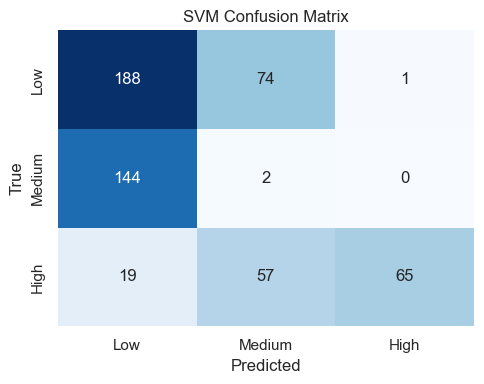

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SVM_PIPELINE = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=2.0, gamma="scale", class_weight="balanced")),
])

SVM_PIPELINE.fit(X_train_feat, y_train)
y_pred_svm = SVM_PIPELINE.predict(X_test_feat)

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm, average="macro")
svm_report = classification_report(
    y_test, y_pred_svm, labels=[0, 1, 2], target_names=["Low", "Medium", "High"], output_dict=True
  )
svm_cm = confusion_matrix(y_test, y_pred_svm, labels=[0, 1, 2])

SVM_RESULTS = {
    "model": "SVM + Band-Power",
    "accuracy": float(svm_acc),
    "macro_f1": float(svm_f1),
    "recall_low": float(svm_report["Low"]["recall"]),
    "recall_medium": float(svm_report["Medium"]["recall"]),
    "recall_high": float(svm_report["High"]["recall"]),
}

print("SVM baseline complete.")
print(SVM_RESULTS)
print("\nClassification report (SVM):")
print(classification_report(y_test, y_pred_svm, labels=[0, 1, 2], target_names=["Low", "Medium", "High"]))

plt.figure(figsize=(5, 4))
sns.heatmap(
    svm_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"],
)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## 9. Model 2 - EEGNet (Primary Deep Learning Model)

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

if not TORCH_AVAILABLE:
    raise ImportError("PyTorch is required for Section 9. Install torch and rerun.")

class EEGNet(nn.Module):
    def __init__(
        self,
        n_classes: int = 3,
        n_channels: int = 62,
        n_times: int = 500,
        F1: int = 8,
        D: int = 2,
        F2: int = 16,
        kernel_t: int = 64,
        dropout: float = 0.5,
    ):
        super().__init__()

        self.temporal_conv = nn.Conv2d(
            in_channels=1,
            out_channels=F1,
            kernel_size=(1, kernel_t),
            padding=(0, kernel_t // 2),
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(F1)

        self.depthwise = nn.Conv2d(
            in_channels=F1,
            out_channels=F1 * D,
            kernel_size=(n_channels, 1),
            groups=F1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(F1 * D)
        self.pool1 = nn.AvgPool2d((1, 4))
        self.drop1 = nn.Dropout(dropout)

        self.sep_dw = nn.Conv2d(
            in_channels=F1 * D,
            out_channels=F1 * D,
            kernel_size=(1, 16),
            padding=(0, 8),
            groups=F1 * D,
            bias=False,
        )
        self.sep_pw = nn.Conv2d(in_channels=F1 * D, out_channels=F2, kernel_size=(1, 1), bias=False)
        self.bn3 = nn.BatchNorm2d(F2)
        self.pool2 = nn.AvgPool2d((1, 8))
        self.drop2 = nn.Dropout(dropout)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            feat = self._forward_features(dummy)
            feat_dim = feat.view(1, -1).shape[1]
        self.classifier = nn.Linear(feat_dim, n_classes)

    def _forward_features(self, x):
        x = self.bn1(self.temporal_conv(x))
        x = self.bn2(self.depthwise(x))
        x = F.elu(x)
        x = self.drop1(self.pool1(x))
        x = self.sep_pw(self.sep_dw(x))
        x = F.elu(self.bn3(x))
        x = self.drop2(self.pool2(x))
        return x

    def forward(self, x):
        x = self._forward_features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

class DeepConvNet(nn.Module):
    def __init__(self, n_classes: int = 3, n_channels: int = 62, dropout: float = 0.3):
        super().__init__()
        # Filters: 16/32/64
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(1, 5), padding=(0, 2), bias=False),
            nn.Conv2d(16, 16, kernel_size=(n_channels, 1), bias=False),
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(1, 2)),
            nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=(1, 5), padding=(0, 2), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(1, 2)),
            nn.Dropout(dropout),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=(1, 5), padding=(0, 2), bias=False),
            nn.BatchNorm2d(64),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=(1, 2)),
            nn.Dropout(dropout),
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, n_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x).flatten(1)
        return self.fc(x)

class CNNLSTM(nn.Module):
    def __init__(self, n_classes: int = 3, n_channels: int = 62, lstm_units: int = 64, dropout: float = 0.3):
        super().__init__()
        # Input expected: (batch, 1, channels, time)
        self.conv1 = nn.Conv1d(n_channels, 16, kernel_size=7, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(16)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=7, padding=3, bias=False)
        self.bn2 = nn.BatchNorm1d(32)
        self.conv3 = nn.Conv1d(32, 64, kernel_size=7, padding=3, bias=False)
        self.bn3 = nn.BatchNorm1d(64)
        self.drop = nn.Dropout(dropout)
        self.lstm = nn.LSTM(input_size=64, hidden_size=lstm_units, num_layers=1, batch_first=True)
        self.fc = nn.Linear(lstm_units, n_classes)

    def forward(self, x):
        x = x.squeeze(1)  # (B, C, T)
        x = self.drop(F.elu(self.bn1(self.conv1(x))))
        x = self.drop(F.elu(self.bn2(self.conv2(x))))
        x = self.drop(F.elu(self.bn3(self.conv3(x))))
        x = x.transpose(1, 2)  # (B, T, 64)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

n_channels = X_train_model.shape[1]
n_times = X_train_model.shape[2]

EEGNET_MODEL = EEGNet(n_classes=3, n_channels=n_channels, n_times=n_times, dropout=0.5)
DEEPCONVNET_MODEL = DeepConvNet(n_classes=3, n_channels=n_channels, dropout=0.3)
CNNLSTM_MODEL = CNNLSTM(n_classes=3, n_channels=n_channels, lstm_units=64, dropout=0.3)

print("Model definitions ready:")
print("- EEGNet")
print("- DeepConvNet")
print("- CNN-LSTM")

Model definitions ready:
- EEGNet
- DeepConvNet
- CNN-LSTM


Training device: cuda
GPU: NVIDIA RTX PRO 5000 Blackwell
CUDA capability: (12, 0)
[DeepConvNet] Epoch 01/50 | train_loss=0.8245 train_acc=0.709 | val_loss=0.5275 val_acc=0.905
[DeepConvNet] Epoch 02/50 | train_loss=0.3217 train_acc=0.935 | val_loss=0.2596 val_acc=0.920
[DeepConvNet] Epoch 03/50 | train_loss=0.1785 train_acc=0.966 | val_loss=0.2881 val_acc=0.891
[DeepConvNet] Epoch 04/50 | train_loss=0.1220 train_acc=0.975 | val_loss=0.2468 val_acc=0.910
[DeepConvNet] Epoch 05/50 | train_loss=0.0977 train_acc=0.985 | val_loss=0.2225 val_acc=0.920
[DeepConvNet] Epoch 06/50 | train_loss=0.0665 train_acc=0.995 | val_loss=0.2440 val_acc=0.925
[DeepConvNet] Epoch 07/50 | train_loss=0.0559 train_acc=0.994 | val_loss=0.1637 val_acc=0.970
[DeepConvNet] Epoch 08/50 | train_loss=0.0503 train_acc=0.990 | val_loss=0.1948 val_acc=0.945
[DeepConvNet] Epoch 09/50 | train_loss=0.0479 train_acc=0.993 | val_loss=0.1300 val_acc=0.955
[DeepConvNet] Epoch 10/50 | train_loss=0.0434 train_acc=0.990 | val_loss

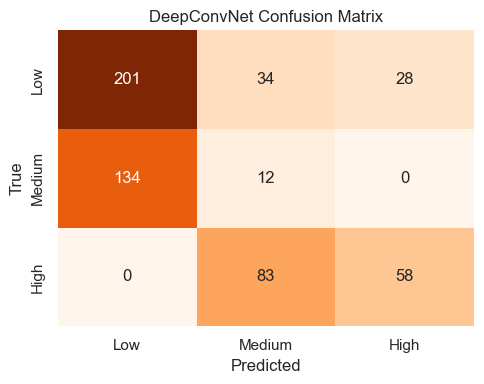

[CNN-LSTM] Epoch 01/50 | train_loss=1.0955 train_acc=0.386 | val_loss=1.0886 val_acc=0.393
[CNN-LSTM] Epoch 02/50 | train_loss=1.0652 train_acc=0.468 | val_loss=1.0804 val_acc=0.373
[CNN-LSTM] Epoch 03/50 | train_loss=1.0253 train_acc=0.517 | val_loss=1.0657 val_acc=0.423
[CNN-LSTM] Epoch 04/50 | train_loss=0.9734 train_acc=0.542 | val_loss=1.0548 val_acc=0.443
[CNN-LSTM] Epoch 05/50 | train_loss=0.9201 train_acc=0.600 | val_loss=1.0573 val_acc=0.453
[CNN-LSTM] Epoch 06/50 | train_loss=0.8745 train_acc=0.611 | val_loss=1.0513 val_acc=0.488
[CNN-LSTM] Epoch 07/50 | train_loss=0.8273 train_acc=0.637 | val_loss=1.0314 val_acc=0.502
[CNN-LSTM] Epoch 08/50 | train_loss=0.7921 train_acc=0.681 | val_loss=1.0775 val_acc=0.498
[CNN-LSTM] Epoch 09/50 | train_loss=0.7417 train_acc=0.690 | val_loss=1.0989 val_acc=0.502
[CNN-LSTM] Epoch 10/50 | train_loss=0.7162 train_acc=0.677 | val_loss=1.0692 val_acc=0.512
[CNN-LSTM] Epoch 11/50 | train_loss=0.6470 train_acc=0.719 | val_loss=1.0908 val_acc=0.572

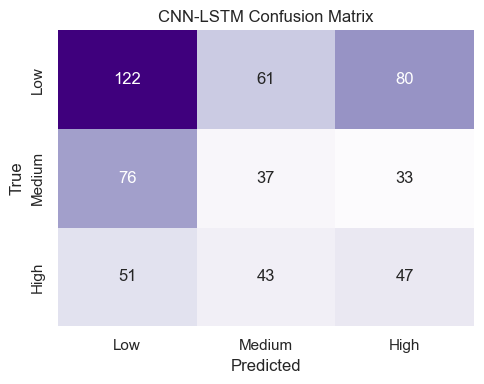

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import TensorDataset, DataLoader

SPEED_MODE = True

# Requested training settings
BATCH_SIZE = 32
MAX_EPOCHS = 50
PATIENCE = 8
LR_DEEPCONVNET = 1e-3
LR_CNNLSTM = 5e-4  # allowed range: 5e-4 to 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA capability: {torch.cuda.get_device_capability(0)}")

if SPEED_MODE and device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

# Split training windows into train/val
idx = np.arange(len(y_train))
train_idx, val_idx = train_test_split(
    idx, test_size=0.2, random_state=SEED, stratify=y_train
)

X_tr = X_train_model[train_idx]
y_tr = y_train[train_idx]
X_val = X_train_model[val_idx]
y_val = y_train[val_idx]

# Model input shape: (batch, 1, channels, time)
X_tr_t = torch.tensor(X_tr, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test_model, dtype=torch.float32).unsqueeze(1)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

pin_mem = device.type == "cuda"
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH_SIZE, shuffle=True, pin_memory=pin_mem)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin_mem)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin_mem)

class_weights = compute_class_weight(class_weight="balanced", classes=np.array([0, 1, 2]), y=y_tr)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)

def train_and_eval(model: nn.Module, model_name: str, lr: float):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )

    use_amp = device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    history_local = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        tr_loss_sum, tr_correct, tr_total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            tr_loss_sum += loss.item() * yb.size(0)
            tr_correct += (logits.argmax(dim=1) == yb).sum().item()
            tr_total += yb.size(0)

        tr_loss = tr_loss_sum / max(tr_total, 1)
        tr_acc = tr_correct / max(tr_total, 1)

        model.eval()
        va_loss_sum, va_correct, va_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                with torch.amp.autocast("cuda", enabled=use_amp):
                    logits = model(xb)
                    loss = criterion(logits, yb)
                va_loss_sum += loss.item() * yb.size(0)
                va_correct += (logits.argmax(dim=1) == yb).sum().item()
                va_total += yb.size(0)

        va_loss = va_loss_sum / max(va_total, 1)
        va_acc = va_correct / max(va_total, 1)
        scheduler.step(va_loss)

        history_local["train_loss"].append(tr_loss)
        history_local["train_acc"].append(tr_acc)
        history_local["val_loss"].append(va_loss)
        history_local["val_acc"].append(va_acc)

        print(
            f"[{model_name}] Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"train_loss={tr_loss:.4f} train_acc={tr_acc:.3f} | "
            f"val_loss={va_loss:.4f} val_acc={va_acc:.3f}"
        )

        if va_loss < best_val_loss - 1e-5:
            best_val_loss = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"[{model_name}] Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(xb)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_true.append(yb.numpy())

    y_pred = np.concatenate(all_preds)
    y_true_eval = np.concatenate(all_true)

    acc = accuracy_score(y_true_eval, y_pred)
    f1m = f1_score(y_true_eval, y_pred, average="macro")
    report = classification_report(
        y_true_eval, y_pred, labels=[0, 1, 2], target_names=["Low", "Medium", "High"], output_dict=True
    )
    cm = confusion_matrix(y_true_eval, y_pred, labels=[0, 1, 2])

    result = {
        "model": model_name,
        "accuracy": float(acc),
        "macro_f1": float(f1m),
        "recall_low": float(report["Low"]["recall"]),
        "recall_medium": float(report["Medium"]["recall"]),
        "recall_high": float(report["High"]["recall"]),
    }
    return result, y_true_eval, y_pred, cm, history_local

# Train DeepConvNet
DEEPCONVNET_RESULTS, y_true_deepconvnet, y_pred_deepconvnet, deepconvnet_cm, history_deepconvnet = train_and_eval(
    DEEPCONVNET_MODEL, model_name="DeepConvNet", lr=LR_DEEPCONVNET
)

print("\nDeepConvNet complete.")
print(DEEPCONVNET_RESULTS)

plt.figure(figsize=(5, 4))
sns.heatmap(
    deepconvnet_cm, annot=True, fmt="d", cmap="Oranges", cbar=False,
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"],
)
plt.title("DeepConvNet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Train CNN-LSTM
CNNLSTM_RESULTS, y_true_cnnlstm, y_pred_cnnlstm, cnnlstm_cm, history_cnnlstm = train_and_eval(
    CNNLSTM_MODEL, model_name="CNN-LSTM", lr=LR_CNNLSTM
)

print("\nCNN-LSTM complete.")
print(CNNLSTM_RESULTS)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cnnlstm_cm, annot=True, fmt="d", cmap="Purples", cbar=False,
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"],
)
plt.title("CNN-LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## 10. Evaluation Utilities and Metrics

In [12]:
from sklearn.metrics import precision_recall_fscore_support

def compute_metrics_dict(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    acc = float(accuracy_score(y_true, y_pred))
    macro_f1 = float(f1_score(y_true, y_pred, average="macro"))
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1, 2], zero_division=0
    )
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "precision_low": float(p[0]),
        "precision_medium": float(p[1]),
        "precision_high": float(p[2]),
        "recall_low": float(r[0]),
        "recall_medium": float(r[1]),
        "recall_high": float(r[2]),
        "f1_low": float(f1[0]),
        "f1_medium": float(f1[1]),
        "f1_high": float(f1[2]),
    }

def plot_confusion(y_true: np.ndarray, y_pred: np.ndarray, title: str, cmap: str = "Blues") -> np.ndarray:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap, cbar=False,
        xticklabels=["Low", "Medium", "High"],
        yticklabels=["Low", "Medium", "High"],
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
    return cm

def plot_training_history(hist: dict):
    if not hist or len(hist.get("train_loss", [])) == 0:
        print("No training history available.")
        return
    epochs = np.arange(1, len(hist["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, hist["train_loss"], label="Train", lw=1.8)
    axes[0].plot(epochs, hist["val_loss"], label="Val", lw=1.8)
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, hist["train_acc"], label="Train", lw=1.8)
    axes[1].plot(epochs, hist["val_acc"], label="Val", lw=1.8)
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

print("Metrics utilities ready.")

Metrics utilities ready.


## 11. Results Comparison (SVM vs EEGNet)

,model,accuracy,macro_f1,recall_low,recall_medium,recall_high
0,SVM + Band-Power,0.4636,0.4182,0.7148,0.0137,0.4610
1,DeepConvNet,0.4927,0.4235,0.7643,0.0822,0.4113
2,CNN-LSTM,0.3745,0.3489,0.4639,0.2534,0.3333


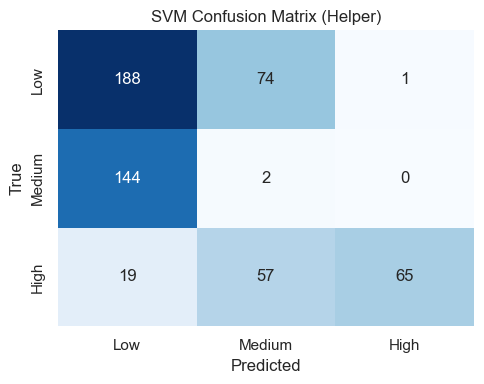

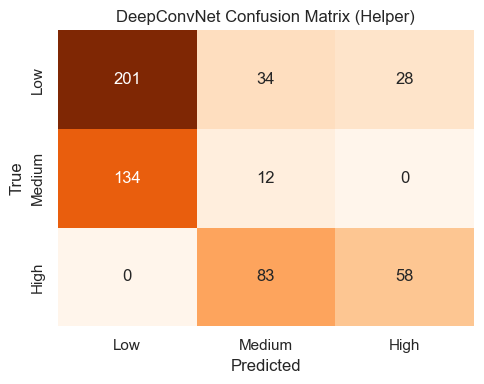

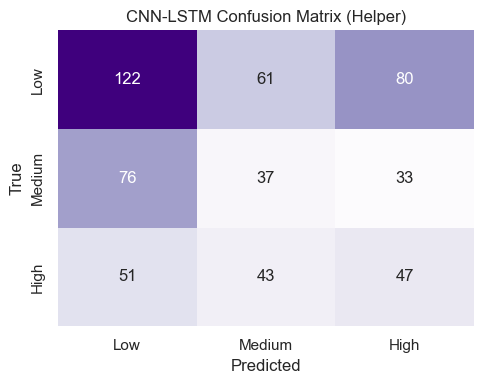

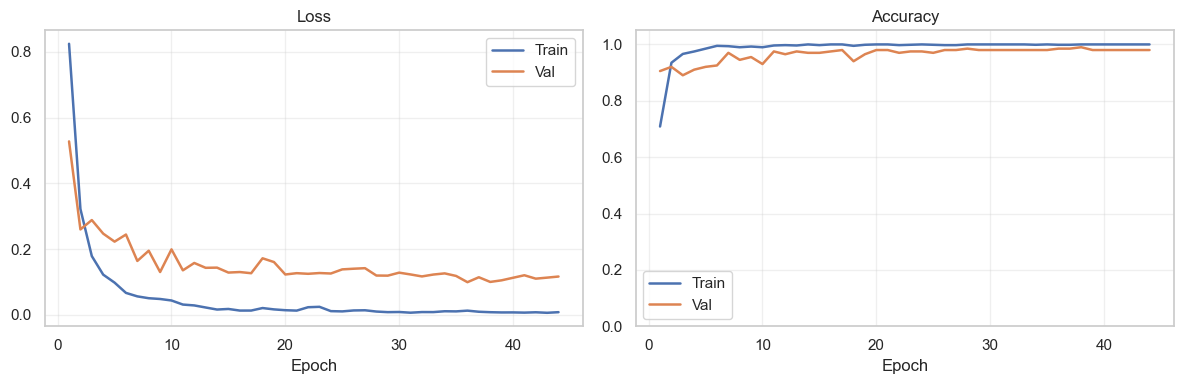

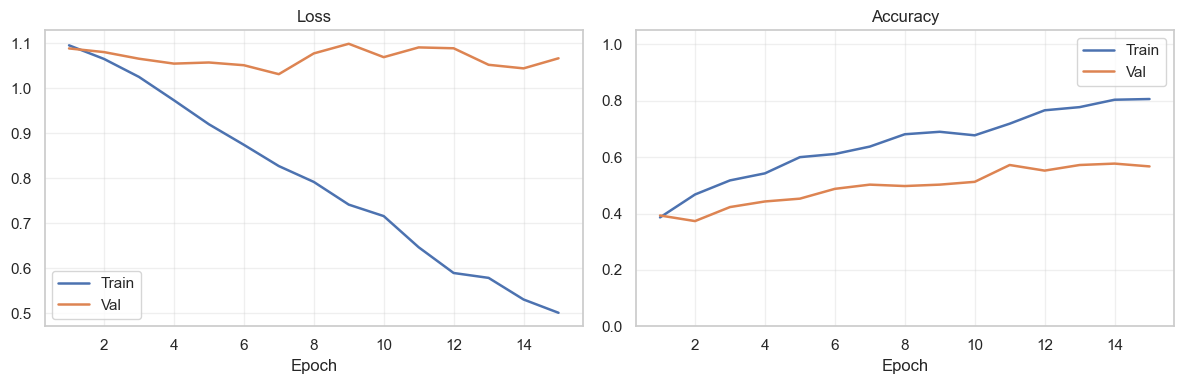

In [13]:
results_rows = []
if "SVM_RESULTS" in globals():
    results_rows.append(SVM_RESULTS)
if "EEGNET_RESULTS" in globals():
    results_rows.append(EEGNET_RESULTS)
if "DEEPCONVNET_RESULTS" in globals():
    results_rows.append(DEEPCONVNET_RESULTS)
if "CNNLSTM_RESULTS" in globals():
    results_rows.append(CNNLSTM_RESULTS)

if not results_rows:
    raise RuntimeError("No model results found. Run model training sections first.")

RESULTS_DF = pd.DataFrame(results_rows)
display(RESULTS_DF.round(4))

if "y_pred_svm" in globals():
    _ = plot_confusion(y_test, y_pred_svm, title="SVM Confusion Matrix (Helper)", cmap="Blues")

if "y_pred_eegnet" in globals():
    _ = plot_confusion(y_test, y_pred_eegnet, title="EEGNet Confusion Matrix (Helper)", cmap="Greens")

if "y_pred_deepconvnet" in globals():
    _ = plot_confusion(y_test, y_pred_deepconvnet, title="DeepConvNet Confusion Matrix (Helper)", cmap="Oranges")

if "y_pred_cnnlstm" in globals():
    _ = plot_confusion(y_test, y_pred_cnnlstm, title="CNN-LSTM Confusion Matrix (Helper)", cmap="Purples")

if "history" in globals():
    plot_training_history(history)
if "history_deepconvnet" in globals():
    plot_training_history(history_deepconvnet)
if "history_cnnlstm" in globals():
    plot_training_history(history_cnnlstm)

## 12. Error Analysis and Interpretation

In [14]:
analysis_rows = []

if "y_pred_svm" in globals():
    m = compute_metrics_dict(y_test, y_pred_svm)
    m["model"] = "SVM + Band-Power"
    analysis_rows.append(m)

if "y_pred_eegnet" in globals():
    m = compute_metrics_dict(y_test, y_pred_eegnet)
    m["model"] = "EEGNet"
    analysis_rows.append(m)

if "y_pred_deepconvnet" in globals():
    m = compute_metrics_dict(y_test, y_pred_deepconvnet)
    m["model"] = "DeepConvNet"
    analysis_rows.append(m)

if "y_pred_cnnlstm" in globals():
    m = compute_metrics_dict(y_test, y_pred_cnnlstm)
    m["model"] = "CNN-LSTM"
    analysis_rows.append(m)

if not analysis_rows:
    raise RuntimeError("No predictions available for error analysis.")

ERROR_ANALYSIS_DF = pd.DataFrame(analysis_rows)[[
    "model", "accuracy", "macro_f1",
    "recall_low", "recall_medium", "recall_high",
    "precision_low", "precision_medium", "precision_high",
]]
display(ERROR_ANALYSIS_DF.round(4))

print("\nError analysis highlights:")
for _, row in ERROR_ANALYSIS_DF.iterrows():
    hardest_class = min([
        ("Low", row["recall_low"]),
        ("Medium", row["recall_medium"]),
        ("High", row["recall_high"]),
    ], key=lambda x: x[1])
    print(
        f"- {row['model']}: hardest class = {hardest_class[0]} "
        f"(recall={hardest_class[1]:.3f}), overall acc={row['accuracy']:.3f}, macro-F1={row['macro_f1']:.3f}"
    )

if len(ERROR_ANALYSIS_DF) >= 2:
    base = ERROR_ANALYSIS_DF.iloc[0]
    comp = ERROR_ANALYSIS_DF.iloc[-1]
    print("\nModel-to-model deltas (last minus first):")
    for k in ["accuracy", "macro_f1", "recall_low", "recall_medium", "recall_high"]:
        print(f"- {k}: {comp[k] - base[k]:+.4f}")

,model,accuracy,macro_f1,recall_low,recall_medium,recall_high,precision_low,precision_medium,precision_high
0,SVM + Band-Power,0.4636,0.4182,0.7148,0.0137,0.4610,0.5356,0.0150,0.9848
1,DeepConvNet,0.4927,0.4235,0.7643,0.0822,0.4113,0.6000,0.0930,0.6744
2,CNN-LSTM,0.3745,0.3489,0.4639,0.2534,0.3333,0.4900,0.2624,0.2938



Error analysis highlights:
- SVM + Band-Power: hardest class = Medium (recall=0.014), overall acc=0.464, macro-F1=0.418
- DeepConvNet: hardest class = Medium (recall=0.082), overall acc=0.493, macro-F1=0.424
- CNN-LSTM: hardest class = Medium (recall=0.253), overall acc=0.375, macro-F1=0.349

Model-to-model deltas (last minus first):
- accuracy: -0.0891
- macro_f1: -0.0693
- recall_low: -0.2510
- recall_medium: +0.2397
- recall_high: -0.1277


## 13. Reproducibility Summary

Include:
- package versions
- random seeds
- hardware/runtime notes
- data source mode used

In [15]:
import json
from datetime import datetime

RUN_TIMESTAMP = datetime.now().isoformat(timespec="seconds")

run_summary = {
    "timestamp": RUN_TIMESTAMP,
    "project_root": str(PROJECT_ROOT),
    "data_source_mode": DATA_SOURCE_MODE,
    "preprocess_mode": PREPROCESS_MODE,
    "preproc_variant": PREPROC_VARIANT,
    "preproc_variant_for_models": (
        PREPROC_VARIANT_FOR_MODELS if "PREPROC_VARIANT_FOR_MODELS" in globals() else PREPROC_VARIANT
    ),
    "seed": SEED,
    "dataset_dir": str(DATASET_DIR),
    "n_subjects_total": int(DF["subject"].nunique()),
    "train_files": int(len(TRAIN_DF)),
    "test_files": int(len(TEST_DF)),
    "channels_used": int(len(COMMON_CHANNELS)),
    "window_sec": float(PREPROC_CONFIG["window_sec"]),
    "resample_hz": float(PREPROC_CONFIG["resample_hz"]),
    "train_shape": tuple(int(x) for x in X_train_model.shape),
    "test_shape": tuple(int(x) for x in X_test_model.shape),
    "package_versions": {
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "mne": mne.__version__,
        "sklearn": sklearn_version,
        "torch": torch.__version__ if TORCH_AVAILABLE else None,
    },
}

if "SVM_RESULTS" in globals():
    run_summary["svm_results"] = SVM_RESULTS
if "EEGNET_RESULTS" in globals():
    run_summary["eegnet_results"] = EEGNET_RESULTS
if "DEEPCONVNET_RESULTS" in globals():
    run_summary["deepconvnet_results"] = DEEPCONVNET_RESULTS
if "CNNLSTM_RESULTS" in globals():
    run_summary["cnnlstm_results"] = CNNLSTM_RESULTS

print(json.dumps(run_summary, indent=2))

SAVE_SUMMARY = True
if SAVE_SUMMARY:
    out_dir = PROJECT_ROOT / "artifacts" / "run_outputs"
    out_dir.mkdir(parents=True, exist_ok=True)

    with open(out_dir / "run_summary.json", "w", encoding="utf-8") as f:
        json.dump(run_summary, f, indent=2)

    if "RESULTS_DF" in globals():
        RESULTS_DF.to_csv(out_dir / "model_results.csv", index=False)
    if "ERROR_ANALYSIS_DF" in globals():
        ERROR_ANALYSIS_DF.to_csv(out_dir / "error_analysis.csv", index=False)

    print(f"Saved run outputs to: {out_dir}")

{
  "timestamp": "2026-04-23T17:27:54",
  "project_root": "C:\\Users\\u5749675\\Desktop\\u5749675\\eeg-workload-classification",
  "data_source_mode": "local",
  "preprocess_mode": "dev",
  "preproc_variant": "core",
  "preproc_variant_for_models": "core+EA",
  "seed": 42,
  "dataset_dir": "C:\\Users\\u5749675\\Desktop\\u5749675\\eeg-workload-classification\\dataset",
  "n_subjects_total": 29,
  "train_files": 174,
  "test_files": 87,
  "channels_used": 62,
  "window_sec": 6.0,
  "resample_hz": 250.0,
  "train_shape": [
    1001,
    62,
    1500
  ],
  "test_shape": [
    550,
    62,
    1500
  ],
  "package_versions": {
    "python": "3.14.3",
    "numpy": "2.4.4",
    "pandas": "3.0.2",
    "mne": "1.12.1",
    "sklearn": "1.8.0",
    "torch": "2.11.0+cu128"
  },
  "svm_results": {
    "model": "SVM + Band-Power",
    "accuracy": 0.4636363636363636,
    "macro_f1": 0.41824469713236273,
    "recall_low": 0.714828897338403,
    "recall_medium": 0.0136986301369863,
    "recall_high": 

## 14. Report Mapping Notes (LO1, LO2, LO3)

Use this section to collect bullet points and references while running experiments.

## 15. Failure Analysis and Targeted Improvement Experiments

This section tests why performance is limited and whether the bottleneck is labels, preprocessing, or model capacity.

Experiments included:
- Binary task (Low vs High) to test label overlap hypothesis.
- Window length sweep (2 s, 4 s, 6 s) with validation macro-F1 selection.
- Class balance and Medium-class confusion diagnostics.
- DeepConvNet tuning (lower LR, higher dropout, weight decay, class weighting).
- CNN-LSTM complexity reduction ablations.
- Additional practical techniques to improve generalization.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score

def print_class_balance(y: np.ndarray, name: str):
    s = pd.Series(y).value_counts().sort_index()
    frac = (s / s.sum()).round(4)
    out = pd.DataFrame({"count": s, "fraction": frac})
    print(f"\n{name} class balance")
    display(out)

def medium_confusion_diagnostics(y_true: np.ndarray, y_pred: np.ndarray, model_name: str):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    print(f"\n[{model_name}] Medium confusion diagnostics")
    print("Confusion matrix rows=true cols=pred, classes=[Low, Medium, High]")
    print(cm)

    medium_total = max(int((y_true == 1).sum()), 1)
    med_to_low = int(((y_true == 1) & (y_pred == 0)).sum())
    med_to_high = int(((y_true == 1) & (y_pred == 2)).sum())
    print(f"Medium -> Low:  {med_to_low}/{medium_total} ({100.0 * med_to_low / medium_total:.1f}%)")
    print(f"Medium -> High: {med_to_high}/{medium_total} ({100.0 * med_to_high / medium_total:.1f}%)")

def binary_low_high_test(X_train_feat: np.ndarray, y_train: np.ndarray, X_test_feat: np.ndarray, y_test: np.ndarray):
    tr_mask = np.isin(y_train, [0, 2])
    te_mask = np.isin(y_test, [0, 2])

    Xtr = X_train_feat[tr_mask]
    ytr = (y_train[tr_mask] == 2).astype(int)  # Low=0, High=1
    Xte = X_test_feat[te_mask]
    yte = (y_test[te_mask] == 2).astype(int)

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
    ])
    clf.fit(Xtr, ytr)
    pred = clf.predict(Xte)

    acc = accuracy_score(yte, pred)
    f1m = f1_score(yte, pred, average="macro")
    cm = confusion_matrix(yte, pred, labels=[0, 1])

    print("\nBinary Low-vs-High experiment")
    print(f"Accuracy: {acc:.4f} | Macro-F1: {f1m:.4f}")
    print("Confusion matrix rows=true cols=pred, classes=[Low, High]")
    print(cm)
    print(classification_report(yte, pred, target_names=["Low", "High"]))

    return {"accuracy": float(acc), "macro_f1": float(f1m)}

print_class_balance(y_train, "Train")
print_class_balance(y_test, "Test")

if "y_pred_svm" in globals():
    medium_confusion_diagnostics(y_test, y_pred_svm, "SVM")
if "y_pred_eegnet" in globals():
    medium_confusion_diagnostics(y_test, y_pred_eegnet, "EEGNet")
if "y_pred_deepconvnet" in globals():
    medium_confusion_diagnostics(y_test, y_pred_deepconvnet, "DeepConvNet")
if "y_pred_cnnlstm" in globals():
    medium_confusion_diagnostics(y_test, y_pred_cnnlstm, "CNN-LSTM")

if "X_train_feat" in globals() and "X_test_feat" in globals():
    BINARY_RESULTS = binary_low_high_test(X_train_feat, y_train, X_test_feat, y_test)
else:
    print("Run Section 7 first to create X_train_feat and X_test_feat, then rerun this cell.")


Train class balance


,count,fraction
0,438,0.4376
1,310,0.3097
2,253,0.2527



Test class balance


,count,fraction
0,263,0.4782
1,146,0.2655
2,141,0.2564



[SVM] Medium confusion diagnostics
Confusion matrix rows=true cols=pred, classes=[Low, Medium, High]
[[188  74   1]
 [144   2   0]
 [ 19  57  65]]
Medium -> Low:  144/146 (98.6%)
Medium -> High: 0/146 (0.0%)

[DeepConvNet] Medium confusion diagnostics
Confusion matrix rows=true cols=pred, classes=[Low, Medium, High]
[[201  34  28]
 [134  12   0]
 [  0  83  58]]
Medium -> Low:  134/146 (91.8%)
Medium -> High: 0/146 (0.0%)

[CNN-LSTM] Medium confusion diagnostics
Confusion matrix rows=true cols=pred, classes=[Low, Medium, High]
[[122  61  80]
 [ 76  37  33]
 [ 51  43  47]]
Medium -> Low:  76/146 (52.1%)
Medium -> High: 33/146 (22.6%)

Binary Low-vs-High experiment
Accuracy: 0.9109 | Macro-F1: 0.9065
Confusion matrix rows=true cols=pred, classes=[Low, High]
[[228  35]
 [  1 140]]
              precision    recall  f1-score   support

         Low       1.00      0.87      0.93       263
        High       0.80      0.99      0.89       141

    accuracy                           0.91    

In [17]:
# Window length sweep: 2s, 4s, 6s
WINDOW_SWEEP_SECONDS = [2.0, 4.0, 6.0]
WINDOW_SWEEP_MAX_FILES_PER_SPLIT = None  # set int for faster debugging, e.g., 30

if "train_run_df" not in globals() or "test_run_df" not in globals():
    raise RuntimeError("Run preprocessing section first so train_run_df/test_run_df exist.")

def _get_split_subset(df: pd.DataFrame, max_files: int | None):
    if max_files is None:
        return df.reset_index(drop=True)
    return df.head(max_files).reset_index(drop=True)

def build_windows_for_cfg(train_df: pd.DataFrame, test_df: pd.DataFrame, cfg_local: dict):
    def _proc(df_split: pd.DataFrame, split_name: str):
        X_list, y_list = [], []
        for row in df_split.itertuples(index=False):
            raw_clean, _ = preprocess_single_block(
                set_file=Path(row.set_file),
                common_channels=COMMON_CHANNELS,
                cfg=cfg_local,
                verbose=False,
                enable_bad_channel_interp=True,
                enable_car=True,
            )
            Xw, yw, _ = make_windows_from_raw(
                raw=raw_clean,
                label=int(row.label),
                window_sec=cfg_local["window_sec"],
                overlap=cfg_local["overlap"],
                artifact_thresh_uv=cfg_local["artifact_thresh_uv"],
                dtype=np.float32,
            )
            if Xw.shape[0] > 0:
                X_list.append(Xw)
                y_list.append(yw)
        if X_list:
            X = np.concatenate(X_list, axis=0).astype(np.float32)
            y = np.concatenate(y_list, axis=0).astype(np.int64)
        else:
            win = int(cfg_local["window_sec"] * cfg_local["resample_hz"])
            X = np.empty((0, len(COMMON_CHANNELS), win), dtype=np.float32)
            y = np.empty((0,), dtype=np.int64)
        return X, y

    Xtr_raw, ytr = _proc(train_df, "train")
    Xte_raw, yte = _proc(test_df, "test")
    Xtr, Xte, _ = zscore_train_test(Xtr_raw, Xte_raw)
    return Xtr, ytr, Xte, yte

def eval_window_length(window_sec: float):
    cfg_local = dict(PREPROC_CONFIG)
    cfg_local["window_sec"] = float(window_sec)

    tr_df = _get_split_subset(train_run_df, WINDOW_SWEEP_MAX_FILES_PER_SPLIT)
    te_df = _get_split_subset(test_run_df, WINDOW_SWEEP_MAX_FILES_PER_SPLIT)

    Xtr, ytr, Xte, yte = build_windows_for_cfg(tr_df, te_df, cfg_local)

    # Validation split from train windows
    idx = np.arange(len(ytr))
    tr_idx, va_idx = train_test_split(idx, test_size=0.2, random_state=SEED, stratify=ytr)

    Xtr2 = Xtr[tr_idx]
    ytr2 = ytr[tr_idx]
    Xva = Xtr[va_idx]
    yva = ytr[va_idx]

    Ftr, _ = extract_band_power_features(Xtr2, sfreq=cfg_local["resample_hz"], bands=BANDS, nperseg=128, chunk_size=1024)
    Fva, _ = extract_band_power_features(Xva, sfreq=cfg_local["resample_hz"], bands=BANDS, nperseg=128, chunk_size=1024)
    Fte, _ = extract_band_power_features(Xte, sfreq=cfg_local["resample_hz"], bands=BANDS, nperseg=128, chunk_size=1024)

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
    ])
    clf.fit(Ftr, ytr2)
    yva_pred = clf.predict(Fva)
    yte_pred = clf.predict(Fte)

    val_f1 = f1_score(yva, yva_pred, average="macro")
    test_f1 = f1_score(yte, yte_pred, average="macro")
    test_acc = accuracy_score(yte, yte_pred)

    return {
        "window_sec": window_sec,
        "val_macro_f1": float(val_f1),
        "test_macro_f1": float(test_f1),
        "test_accuracy": float(test_acc),
        "n_train_windows": int(len(ytr)),
        "n_test_windows": int(len(yte)),
    }

WINDOW_SWEEP_RESULTS = []
for ws in WINDOW_SWEEP_SECONDS:
    print(f"Running window sweep for {ws:.0f}s...")
    WINDOW_SWEEP_RESULTS.append(eval_window_length(ws))

WINDOW_SWEEP_DF = pd.DataFrame(WINDOW_SWEEP_RESULTS).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
display(WINDOW_SWEEP_DF.round(4))

BEST_WINDOW_SEC = float(WINDOW_SWEEP_DF.iloc[0]["window_sec"])
print(f"Best window by validation macro-F1: {BEST_WINDOW_SEC:.0f}s")

Running window sweep for 2s...
Running window sweep for 4s...
Running window sweep for 6s...


,window_sec,val_macro_f1,test_macro_f1,test_accuracy,n_train_windows,n_test_windows
0,6.0,0.9559,0.4550,0.5891,1001,550
1,4.0,0.9492,0.4119,0.5310,1686,951
2,2.0,0.8919,0.4354,0.5029,4044,2249


Best window by validation macro-F1: 6s


In [18]:
# DeepConvNet tuning and CNN-LSTM complexity ablations

if "X_train_model" not in globals() or "X_test_model" not in globals():
    raise RuntimeError("Run preprocessing and EA sections first.")

# Rebuild loaders for controlled ablations
idx = np.arange(len(y_train))
train_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=SEED, stratify=y_train)

X_tr = X_train_model[train_idx]
y_tr = y_train[train_idx]
X_val = X_train_model[val_idx]
y_val = y_train[val_idx]

X_tr_t = torch.tensor(X_tr, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test_model, dtype=torch.float32).unsqueeze(1)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

pin_mem = (torch.cuda.is_available())
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True, pin_memory=pin_mem)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False, pin_memory=pin_mem)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False, pin_memory=pin_mem)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"

def train_eval_config(
    model: nn.Module,
    model_name: str,
    lr: float,
    weight_decay: float,
    use_class_weights: bool = True,
    max_epochs: int = 50,
    patience: int = 8,
):
    model = model.to(device)

    if use_class_weights:
        cw = compute_class_weight(class_weight="balanced", classes=np.array([0, 1, 2]), y=y_tr)
        cw_t = torch.tensor(cw, dtype=torch.float32, device=device)
        criterion = nn.CrossEntropyLoss(weight=cw_t)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        tr_loss_sum, tr_correct, tr_total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(xb)
                loss = criterion(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            tr_loss_sum += loss.item() * yb.size(0)
            tr_correct += (logits.argmax(dim=1) == yb).sum().item()
            tr_total += yb.size(0)

        model.eval()
        va_loss_sum, va_correct, va_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                with torch.amp.autocast("cuda", enabled=use_amp):
                    logits = model(xb)
                    loss = criterion(logits, yb)
                va_loss_sum += loss.item() * yb.size(0)
                va_correct += (logits.argmax(dim=1) == yb).sum().item()
                va_total += yb.size(0)

        va_loss = va_loss_sum / max(va_total, 1)
        va_acc = va_correct / max(va_total, 1)
        scheduler.step(va_loss)
        print(f"[{model_name}] Ep {epoch:02d}/{max_epochs} val_loss={va_loss:.4f} val_acc={va_acc:.3f}")

        if va_loss < best_val_loss - 1e-5:
            best_val_loss = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[{model_name}] Early stopping")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    preds, true = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(xb)
            preds.append(logits.argmax(dim=1).cpu().numpy())
            true.append(yb.numpy())

    y_pred = np.concatenate(preds)
    y_true_local = np.concatenate(true)
    rep = classification_report(y_true_local, y_pred, labels=[0, 1, 2], target_names=["Low", "Medium", "High"], output_dict=True)
    row = {
        "model": model_name,
        "accuracy": float(accuracy_score(y_true_local, y_pred)),
        "macro_f1": float(f1_score(y_true_local, y_pred, average="macro")),
        "recall_low": float(rep["Low"]["recall"]),
        "recall_medium": float(rep["Medium"]["recall"]),
        "recall_high": float(rep["High"]["recall"]),
    }
    return row, y_true_local, y_pred

class SmallCNNLSTM(nn.Module):
    def __init__(self, n_classes: int = 3, n_channels: int = 62, lstm_units: int = 32, dropout: float = 0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(n_channels, 8, kernel_size=7, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(8)
        self.conv2 = nn.Conv1d(8, 16, kernel_size=7, padding=3, bias=False)
        self.bn2 = nn.BatchNorm1d(16)
        self.drop = nn.Dropout(dropout)
        self.lstm = nn.LSTM(input_size=16, hidden_size=lstm_units, num_layers=1, batch_first=True)
        self.fc = nn.Linear(lstm_units, n_classes)

    def forward(self, x):
        x = x.squeeze(1)
        x = self.drop(F.elu(self.bn1(self.conv1(x))))
        x = self.drop(F.elu(self.bn2(self.conv2(x))))
        x = x.transpose(1, 2)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class CNNNoRNN(nn.Module):
    def __init__(self, n_classes: int = 3, n_channels: int = 62, dropout: float = 0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(n_channels, 16, kernel_size=7, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(16)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=7, padding=3, bias=False)
        self.bn2 = nn.BatchNorm1d(32)
        self.drop = nn.Dropout(dropout)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, n_classes)

    def forward(self, x):
        x = x.squeeze(1)
        x = self.drop(F.elu(self.bn1(self.conv1(x))))
        x = self.drop(F.elu(self.bn2(self.conv2(x))))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

n_channels = X_train_model.shape[1]

ABLATION_ROWS = []

# Tuned DeepConvNet: lower LR, higher dropout, higher weight decay, class weights on
deep_tuned = DeepConvNet(n_classes=3, n_channels=n_channels, dropout=0.4)
row, y_true_deep_tuned, y_pred_deep_tuned = train_eval_config(
    model=deep_tuned,
    model_name="DeepConvNet_tuned",
    lr=3e-4,
    weight_decay=5e-4,
    use_class_weights=True,
    max_epochs=50,
    patience=8,
)
ABLATION_ROWS.append(row)

# Smaller CNN-LSTM
small_cnnlstm = SmallCNNLSTM(n_classes=3, n_channels=n_channels, lstm_units=32, dropout=0.3)
row, y_true_small_cnnlstm, y_pred_small_cnnlstm = train_eval_config(
    model=small_cnnlstm,
    model_name="CNNLSTM_small",
    lr=5e-4,
    weight_decay=1e-4,
    use_class_weights=True,
    max_epochs=50,
    patience=8,
)
ABLATION_ROWS.append(row)

# Remove recurrent layer test
cnn_no_rnn = CNNNoRNN(n_classes=3, n_channels=n_channels, dropout=0.3)
row, y_true_cnn_no_rnn, y_pred_cnn_no_rnn = train_eval_config(
    model=cnn_no_rnn,
    model_name="CNN_no_RNN",
    lr=1e-3,
    weight_decay=1e-4,
    use_class_weights=True,
    max_epochs=50,
    patience=8,
)
ABLATION_ROWS.append(row)

ABLATION_DF = pd.DataFrame(ABLATION_ROWS).sort_values("macro_f1", ascending=False).reset_index(drop=True)
print("\nAblation results")
display(ABLATION_DF.round(4))

for name, yhat in [
    ("DeepConvNet_tuned", y_pred_deep_tuned),
    ("CNNLSTM_small", y_pred_small_cnnlstm),
    ("CNN_no_RNN", y_pred_cnn_no_rnn),
]:
    medium_confusion_diagnostics(y_test, yhat, name)

[DeepConvNet_tuned] Ep 01/50 val_loss=1.0319 val_acc=0.473
[DeepConvNet_tuned] Ep 02/50 val_loss=0.8064 val_acc=0.672
[DeepConvNet_tuned] Ep 03/50 val_loss=0.5996 val_acc=0.781
[DeepConvNet_tuned] Ep 04/50 val_loss=0.5056 val_acc=0.836
[DeepConvNet_tuned] Ep 05/50 val_loss=0.4765 val_acc=0.836
[DeepConvNet_tuned] Ep 06/50 val_loss=0.5155 val_acc=0.811
[DeepConvNet_tuned] Ep 07/50 val_loss=0.4942 val_acc=0.821
[DeepConvNet_tuned] Ep 08/50 val_loss=0.4918 val_acc=0.831
[DeepConvNet_tuned] Ep 09/50 val_loss=0.4656 val_acc=0.836
[DeepConvNet_tuned] Ep 10/50 val_loss=0.5018 val_acc=0.831
[DeepConvNet_tuned] Ep 11/50 val_loss=0.4706 val_acc=0.831
[DeepConvNet_tuned] Ep 12/50 val_loss=0.4651 val_acc=0.841
[DeepConvNet_tuned] Ep 13/50 val_loss=0.4754 val_acc=0.836
[DeepConvNet_tuned] Ep 14/50 val_loss=0.4255 val_acc=0.846
[DeepConvNet_tuned] Ep 15/50 val_loss=0.4497 val_acc=0.841
[DeepConvNet_tuned] Ep 16/50 val_loss=0.4600 val_acc=0.851
[DeepConvNet_tuned] Ep 17/50 val_loss=0.3885 val_acc=0.8

,model,accuracy,macro_f1,recall_low,recall_medium,recall_high
0,DeepConvNet_tuned,0.5218,0.3651,0.9506,0.0685,0.1915
1,CNNLSTM_small,0.3855,0.3504,0.5247,0.1781,0.3404
2,CNN_no_RNN,0.4145,0.3444,0.6996,0.0411,0.2695



[DeepConvNet_tuned] Medium confusion diagnostics
Confusion matrix rows=true cols=pred, classes=[Low, Medium, High]
[[250   6   7]
 [134  10   2]
 [ 79  35  27]]
Medium -> Low:  134/146 (91.8%)
Medium -> High: 2/146 (1.4%)

[CNNLSTM_small] Medium confusion diagnostics
Confusion matrix rows=true cols=pred, classes=[Low, Medium, High]
[[138  74  51]
 [ 99  26  21]
 [ 45  48  48]]
Medium -> Low:  99/146 (67.8%)
Medium -> High: 21/146 (14.4%)

[CNN_no_RNN] Medium confusion diagnostics
Confusion matrix rows=true cols=pred, classes=[Low, Medium, High]
[[184  56  23]
 [127   6  13]
 [  0 103  38]]
Medium -> Low:  127/146 (87.0%)
Medium -> High: 13/146 (8.9%)


## 16. Preprocessing Decision Guide and Reliability Next Steps

### What is now implemented in this notebook
1. **High-pass and band-pass**: retained through 1-40 Hz filtering in the core pipeline.
2. **Re-reference**: retained as common average reference (CAR).
3. **Bad-channel handling**: retained with robust variance outlier detection plus interpolation.
4. **Window policy**: default is 6-second windows (from prior sweep evidence).
5. **Training-only normalization**: unchanged and leakage-safe.
6. **ICA blink removal**: implemented as an optional branch controlled by `PREPROC_VARIANT` in the preprocessing run cell.

### How to run the two preprocessing variants
- Set `PREPROC_VARIANT = "core"` for baseline.
- Set `PREPROC_VARIANT = "core+ICA"` to enable ICA blink removal with safeguards.
- Keep all other settings fixed when comparing variants.

### ICA safeguards included
- Uses a dedicated high-pass copy for ICA fitting (`ica_fit_l_freq=1.0`).
- Caps excluded ICs (`ica_max_exclude`) to avoid over-cleaning.
- Uses frontal proxy channels when no EOG channel exists.
- Falls back safely to non-ICA processing if ICA fails.

### Promotion rule from optional to default
Promote ICA to default only if it provides consistent gains in macro-F1 and Medium recall without unacceptable runtime increase and without harming Low/High recall stability.

### Recommended next reliability techniques
1. Label smoothing for deep models (for Medium boundary ambiguity).
2. Focal loss for difficult examples near class boundaries.
3. Mild temporal jitter and channel dropout augmentation.
4. Cosine learning-rate schedule with warmup.
5. Small ensemble of lightweight models with averaged logits.
6. Calibration check (temperature scaling) before final reporting.

In [19]:
# Compact summary for experiment review document
print("=== KEY RESULTS SUMMARY ===")

if "RESULTS_DF" in globals():
    print("\nRESULTS_DF:")
    print(RESULTS_DF[["model", "accuracy", "macro_f1", "recall_low", "recall_medium", "recall_high"]].to_string(index=False))

if "BINARY_RESULTS" in globals():
    print("\nBINARY_RESULTS:")
    print(BINARY_RESULTS)

if "WINDOW_SWEEP_DF" in globals():
    print("\nWINDOW_SWEEP_DF:")
    print(WINDOW_SWEEP_DF.to_string(index=False))
    print(f"Best window: {BEST_WINDOW_SEC}s")

if "ABLATION_DF" in globals():
    print("\nABLATION_DF:")
    print(ABLATION_DF.to_string(index=False))

def _medium_diag(y_true, y_pred, name):
    med_total = max(int((y_true == 1).sum()), 1)
    med_to_low = int(((y_true == 1) & (y_pred == 0)).sum())
    med_to_high = int(((y_true == 1) & (y_pred == 2)).sum())
    med_hit = int(((y_true == 1) & (y_pred == 1)).sum())
    print(f"{name}: Medium->Low={med_to_low}, Medium->Medium={med_hit}, Medium->High={med_to_high}, total={med_total}")

print("\nMEDIUM CONFUSION DIAGNOSTICS:")
if "y_pred_svm" in globals():
    _medium_diag(y_test, y_pred_svm, "SVM")
if "y_pred_deepconvnet" in globals():
    _medium_diag(y_test, y_pred_deepconvnet, "DeepConvNet")
if "y_pred_cnnlstm" in globals():
    _medium_diag(y_test, y_pred_cnnlstm, "CNN-LSTM")
if "y_pred_deep_tuned" in globals():
    _medium_diag(y_test, y_pred_deep_tuned, "DeepConvNet_tuned")
if "y_pred_small_cnnlstm" in globals():
    _medium_diag(y_test, y_pred_small_cnnlstm, "CNNLSTM_small")
if "y_pred_cnn_no_rnn" in globals():
    _medium_diag(y_test, y_pred_cnn_no_rnn, "CNN_no_RNN")

=== KEY RESULTS SUMMARY ===

RESULTS_DF:
           model  accuracy  macro_f1  recall_low  recall_medium  recall_high
SVM + Band-Power  0.463636  0.418245    0.714829       0.013699     0.460993
     DeepConvNet  0.492727  0.423509    0.764259       0.082192     0.411348
        CNN-LSTM  0.374545  0.348898    0.463878       0.253425     0.333333

BINARY_RESULTS:
{'accuracy': 0.9108910891089109, 'macro_f1': 0.9064526088298858}

WINDOW_SWEEP_DF:
 window_sec  val_macro_f1  test_macro_f1  test_accuracy  n_train_windows  n_test_windows
        6.0      0.955941       0.454985       0.589091             1001             550
        4.0      0.949169       0.411925       0.531020             1686             951
        2.0      0.891944       0.435433       0.502890             4044            2249
Best window: 6.0s

ABLATION_DF:
            model  accuracy  macro_f1  recall_low  recall_medium  recall_high
DeepConvNet_tuned  0.521818  0.365104    0.950570       0.068493     0.191489
    CNN